# マウナ・ロア気象観測所の$\mathsf{CO_2}$データ
- Python の vega_datasets というライブラリには，学習用の各種データセットが含まれている
- ここでは，その中からマウナ・ロア気象観測所の$\mathsf{CO_2}$データを時系列データとして利用する
- Date は日付 (西暦)，CO2 の単位は ppm (parts per million = 百万分率) である

※ このデータは局所的な大気変動の影響を受けにくい高高度で測定した大気中の$\mathsf{CO_2}$の  
　 データであって，マウナ・ロア山が排出する$\mathsf{CO_2}$のデータではない!!

※ 例によって，各コードの意味は理解しなくてもよい．何をしているのかをよく見ておくこと

In [1]:
# vega_datasets ライブラリから data モジュールをインポートする
from vega_datasets import data

# data モジュールから目的のデータを取得して，変数 co2 に代入する
co2 = data.co2_concentration()

# Date をインデックスとする
co2 = co2.set_index(co2['Date']).drop('Date', axis=1)

# co2 の表示
co2

,CO2
Date,
1958-03-01,315.70
1958-04-01,317.46
1958-05-01,317.51
1958-07-01,315.86
1958-08-01,314.93
...,...
2017-08-01,405.24
2017-09-01,403.27
2017-10-01,403.64


### データの概観

In [2]:
# グラフの表示のために，plotly.express ライブラリをインポートする
import plotly.express as px

# co2 の内容をグラフで表示
display(px.line(co2['CO2']))

In [3]:
import statsmodels.api as sm

# CO2 列を抽出
ts=co2['CO2']

# CO2 列の自己相関を求める
ts_acf = sm.tsa.stattools.acf(ts, nlags=40)
display(ts_acf)

# CO2 列の偏自己相関を求める
ts_pacf = sm.tsa.stattools.pacf(ts, nlags=40, method='ols')
display(ts_pacf)

array([1.        , 0.99472773, 0.98822909, 0.9813844 , 0.97490856,
       0.96914748, 0.96412945, 0.95993444, 0.95678064, 0.95470844,
       0.95326265, 0.95131981, 0.94796645, 0.94283427, 0.93630737,
       0.92941136, 0.92289483, 0.91713842, 0.9121673 , 0.9080318 ,
       0.90488519, 0.90266919, 0.90110685, 0.89908591, 0.89582116,
       0.89079447, 0.88448898, 0.8778678 , 0.87162436, 0.86604512,
       0.86119387, 0.85725893, 0.8542392 , 0.85214077, 0.85057858,
       0.84862238, 0.84530299, 0.84035261, 0.83415926, 0.82765291,
       0.82150236])

array([ 1.        ,  1.00035185, -0.69040191,  0.47643516,  0.29576055,
        0.09037947,  0.11499166,  0.35850617,  0.54033491,  0.54179172,
        0.38437549,  0.34776529, -0.02645613, -0.27528345, -0.02884461,
        0.05948685, -0.01706678, -0.09425293, -0.04766873, -0.09089339,
        0.02588894,  0.05595821,  0.07624719,  0.11023269,  0.0529017 ,
       -0.12632896,  0.03346949,  0.16039556,  0.04417863,  0.00641804,
        0.01617302,  0.01697414,  0.049741  ,  0.00111299, -0.02485232,
        0.06537671, -0.01685648, -0.00625709, -0.01120901,  0.03736676,
       -0.0409201 ])

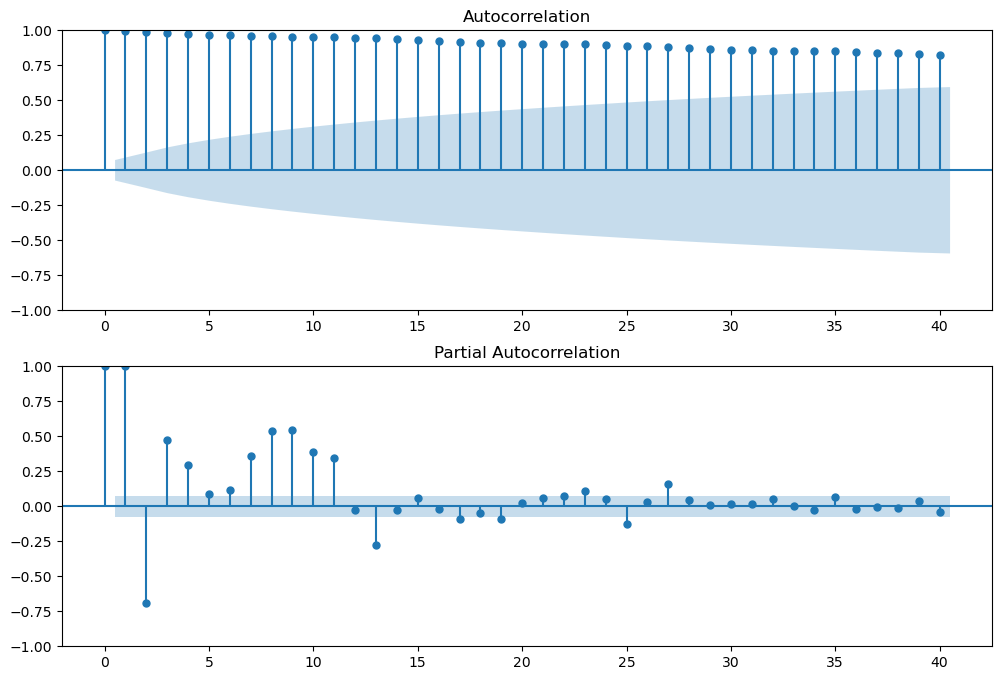

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12,8))

#  自己相関のグラフ
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=40, ax=ax1)

#  偏自己相関のグラフ
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts, lags=40, ax=ax2, method='ols')

### 前処理

In [6]:
# co2 の列の名前の付け替え
dsy = co2.rename(columns={"CO2":"y"})

# 列 "adjusted CO2" の削除（元データに "adjusted CO2" の列がない場合は必要ない）
# dsy = dsy.drop(columns="adjusted CO2")

# Date を ds という名の列とする
dsy['ds'] = co2.index

# 結果の表示
dsy

,y,ds
Date,,
1958-03-01,315.70,1958-03-01
1958-04-01,317.46,1958-04-01
1958-05-01,317.51,1958-05-01
1958-07-01,315.86,1958-07-01
1958-08-01,314.93,1958-08-01
...,...,...
2017-08-01,405.24,2017-08-01
2017-09-01,403.27,2017-09-01
2017-10-01,403.64,2017-10-01


### 将来予測
- Prophet ライブラリ (fbprophet) を使って，co2 の将来の推移を予測する
- Prophet ライブラリは，STAN というベイズ統計モデルを扱うシステムを利用している
  - ベイズ統計モデルは過去の観測値から将来の値を確率的に推定するモデルである

In [7]:
# prophet ライブラリから Prophet モジュールをインポートする
from prophet import Prophet

# 新規に Prophet モデルを生成し，dsy にフィッティングさせる
model = Prophet(weekly_seasonality=False, daily_seasonality=False)
model.fit(dsy)

# model の ds を200か月延長したデータフレームを生成して future に代入する
future = model.make_future_dataframe(periods=200, freq="M")

# future の表示
future

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

17:35:01 - cmdstanpy - INFO - Chain [1] start processing
17:35:02 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,ds
0,1958-03-01
1,1958-04-01
2,1958-05-01
3,1958-07-01
4,1958-08-01
...,...
908,2034-03-31
909,2034-04-30
910,2034-05-31
911,2034-06-30


In [8]:
# future で延長した期間を model を用いて予測し，結果のデータフレームを forecast に代入する
forecast = model.predict(future)

# forecast の表示
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1958-03-01,314.880155,315.661545,316.769878,314.880155,314.880155,1.349372,1.349372,1.349372,1.349372,1.349372,1.349372,0.0,0.0,0.0,316.229527
1,1958-04-01,314.954957,316.981950,318.077050,314.954957,314.954957,2.595602,2.595602,2.595602,2.595602,2.595602,2.595602,0.0,0.0,0.0,317.550559
2,1958-05-01,315.027346,317.520531,318.649094,315.027346,315.027346,3.069187,3.069187,3.069187,3.069187,3.069187,3.069187,0.0,0.0,0.0,318.096533
3,1958-07-01,315.174538,315.412172,316.503133,315.174538,315.174538,0.759527,0.759527,0.759527,0.759527,0.759527,0.759527,0.0,0.0,0.0,315.934065
4,1958-08-01,315.249340,313.291318,314.413087,315.249340,315.249340,-1.366576,-1.366576,-1.366576,-1.366576,-1.366576,-1.366576,0.0,0.0,0.0,313.882764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908,2034-03-31,443.312549,431.157879,464.138616,428.932934,461.486975,2.555247,2.555247,2.555247,2.555247,2.555247,2.555247,0.0,0.0,0.0,445.867796
909,2034-04-30,443.496467,432.178568,464.899945,429.003939,461.876215,3.115480,3.115480,3.115480,3.115480,3.115480,3.115480,0.0,0.0,0.0,446.611947
910,2034-05-31,443.686515,431.473781,464.501696,429.130632,462.248595,2.404032,2.404032,2.404032,2.404032,2.404032,2.404032,0.0,0.0,0.0,446.090548
911,2034-06-30,443.870433,429.898546,463.299002,429.230504,462.605351,0.840838,0.840838,0.840838,0.840838,0.840838,0.840838,0.0,0.0,0.0,444.711270


c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



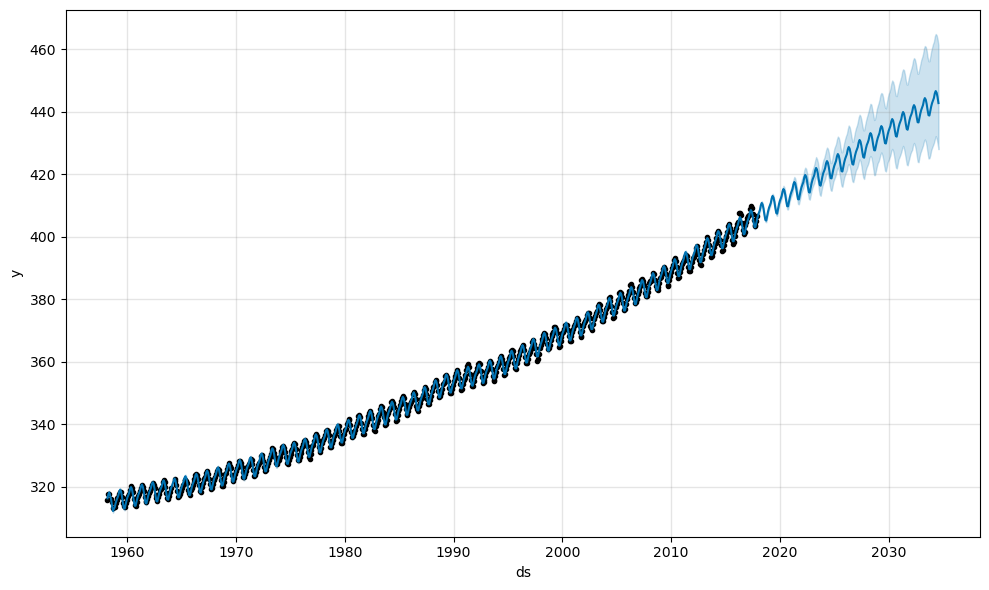

In [9]:
# forecast の予測値 (yhat) のグラフを表示する
# 黒いプロットは観測値
# 色付きの範囲は予測の上下限を表す (デフォルトでは80%信頼区間)
fig1 = model.plot(forecast)

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



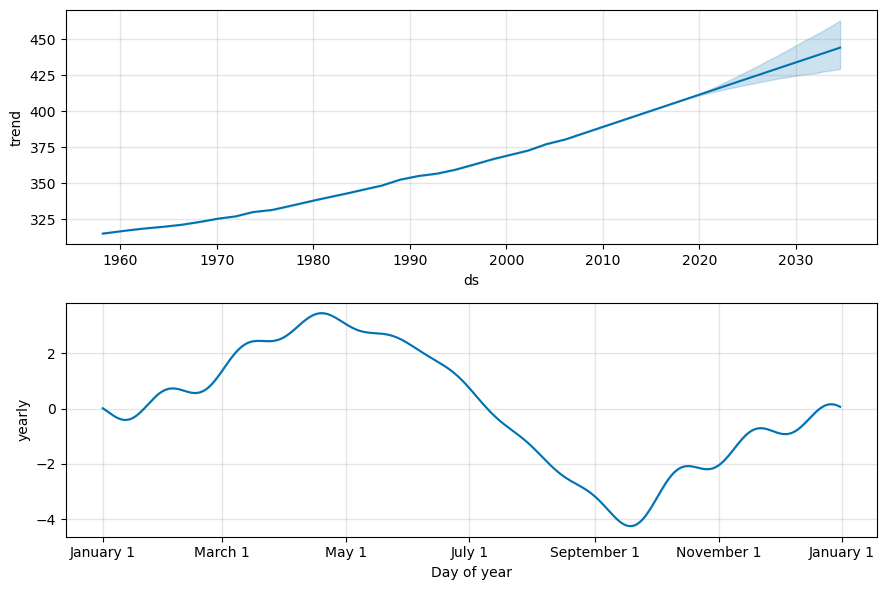

In [10]:
# 傾向変動 (trend) と季節変動 (yearly) のグラフを表示する
fig2 = model.plot_components(forecast)

In [11]:
# forecast のうち，値0の列と，yearly と同じ値の列を除き，並べ替えた列:
# (ds, trend, trend_lower, trend_upper, yhat, yhat_lower, yhat_upper, yearly)
# (日付, 傾向変動, …の下限, …の上限, 予測値, …の下限, …の上限, 季節変動)
# の dataframe を生成して forecast2 に代入

forecast2 = forecast[["ds", "trend", "trend_lower", "trend_upper", "yhat", "yhat_lower", "yhat_upper", "yearly"]]

# forecast2 の先頭10行 (1年分(6,10月欠損)) と末尾12行 (1年分) の表示
display(forecast2.head(10))
display(forecast2.tail(12))

,ds,trend,trend_lower,trend_upper,yhat,yhat_lower,yhat_upper,yearly
0,1958-03-01,314.880155,314.880155,314.880155,316.229527,315.661545,316.769878,1.349372
1,1958-04-01,314.954957,314.954957,314.954957,317.550559,316.981950,318.077050,2.595602
2,1958-05-01,315.027346,315.027346,315.027346,318.096533,317.520531,318.649094,3.069187
3,1958-07-01,315.174538,315.174538,315.174538,315.934065,315.412172,316.503133,0.759527
4,1958-08-01,315.249340,315.249340,315.249340,313.882764,313.291318,314.413087,-1.366576
5,1958-09-01,315.324142,315.324142,315.324142,312.157536,311.596652,312.686955,-3.166606
6,1958-11-01,315.471334,315.471334,315.471334,313.404341,312.850182,313.962675,-2.066993
7,1958-12-01,315.543723,315.543723,315.543723,314.654850,314.095630,315.221928,-0.888873
8,1959-01-01,315.618525,315.618525,315.618525,315.653183,315.129382,316.167246,0.034658
9,1959-02-01,315.693327,315.693327,315.693327,316.359160,315.858573,316.928463,0.665833


,ds,trend,trend_lower,trend_upper,yhat,yhat_lower,yhat_upper,yearly
901,2033-08-31,442.012865,428.290811,459.196742,438.892944,425.026313,456.182100,-3.119920
902,2033-09-30,442.196782,428.383978,459.499016,438.772202,425.094132,456.169082,-3.424580
903,2033-10-31,442.386830,428.483526,459.807420,440.286166,426.140181,457.749708,-2.100664
904,2033-11-30,442.570748,428.582295,460.194289,441.698285,427.655949,459.402564,-0.872463
905,2033-12-31,442.760796,428.682974,460.593235,442.826508,428.498459,460.603757,0.065712
906,2034-01-31,442.950845,428.801019,460.968291,443.588800,429.271813,461.727018,0.637956
907,2034-02-28,443.122501,428.861925,461.218611,444.368333,429.985453,462.397515,1.245832
908,2034-03-31,443.312549,428.932934,461.486975,445.867796,431.157879,464.138616,2.555247
909,2034-04-30,443.496467,429.003939,461.876215,446.611947,432.178568,464.899945,3.115480
910,2034-05-31,443.686515,429.130632,462.248595,446.090548,431.473781,464.501696,2.404032
